Plataforma recomendada para 'AIChatApp': mobile


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/decision_tree.png'

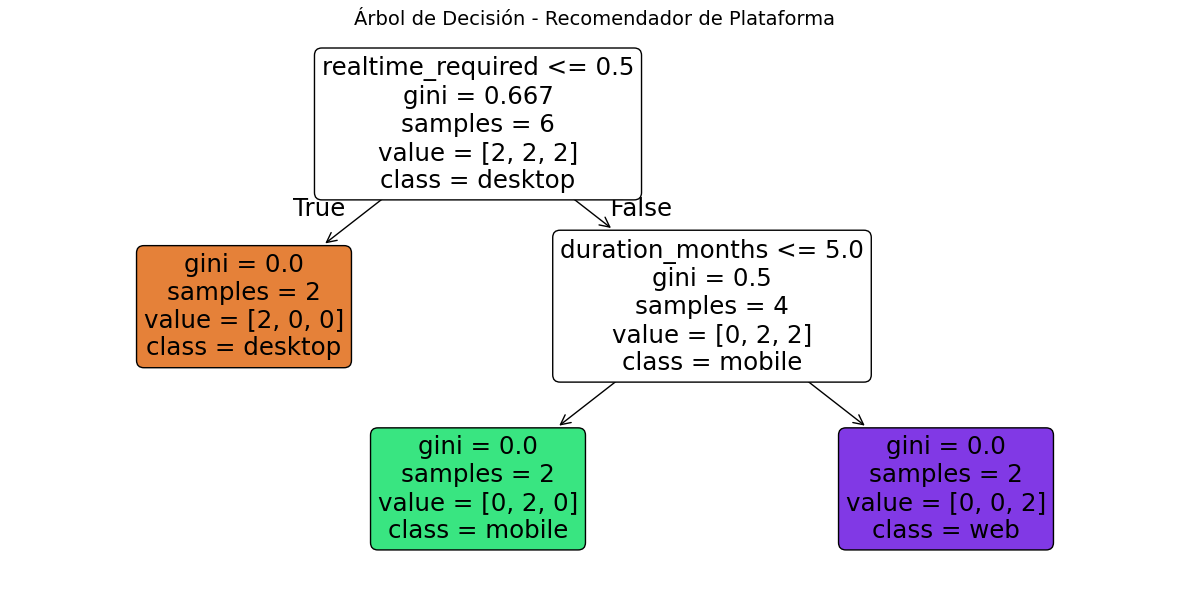

In [1]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn import tree


class Project:
    def __init__(self, name, team_size, budget, duration_months, realtime_required,
                 needs_offline, target_users, recommended_platform=None):
        self.name = name
        self.team_size = team_size
        self.budget = budget
        self.duration_months = duration_months
        self.realtime_required = int(realtime_required)  # convert to 0/1
        self.needs_offline = int(needs_offline)
        self.target_users = target_users
        self.recommended_platform = recommended_platform

    def to_features(self, label_encoder=None):
        target_users_encoded = self.target_users
        if label_encoder:
            target_users_encoded = label_encoder.transform([self.target_users])[0]
        return [self.team_size, self.budget, self.duration_months,
                self.realtime_required, self.needs_offline, target_users_encoded]


class ProjectDataset:
    def __init__(self, projects):
        self.projects = projects
        self._fit_encoders()

    def _fit_encoders(self):
        # Encoder para target_users
        self.target_users_encoder = LabelEncoder()
        all_users = [p.target_users for p in self.projects]
        self.target_users_encoder.fit(all_users)

        # Encoder para recommended_platform (solo proyectos históricos)
        self.platform_encoder = LabelEncoder()
        historical_platforms = [p.recommended_platform for p in self.projects
                                if p.recommended_platform is not None]
        self.platform_encoder.fit(historical_platforms)

    def get_X_y(self):
        historical = [p for p in self.projects if p.recommended_platform is not None]

        X = [p.to_features(self.target_users_encoder) for p in historical]
        y = self.platform_encoder.transform([p.recommended_platform for p in historical])

        return X, y

    def decode_platform(self, label):
        return self.platform_encoder.inverse_transform([label])[0]


class PlatformRecommender:
    def __init__(self):
        self.model = DecisionTreeClassifier(random_state=42)
        self.dataset = None

    def train(self, dataset: ProjectDataset):
        self.dataset = dataset
        X, y = dataset.get_X_y()
        self.model.fit(X, y)

    def predict(self, project: Project):
        features = project.to_features(self.dataset.target_users_encoder)
        prediction = self.model.predict([features])[0]
        return self.dataset.decode_platform(prediction)


class PlatformRecommenderVisualizer:
    def plot_tree(self, recommender: PlatformRecommender):
        model = recommender.model
        model_classes = recommender.dataset.platform_encoder.classes_

        plt.figure(figsize=(12, 6))
        tree.plot_tree(
            model,
            feature_names=["team_size", "budget", "duration_months",
                            "realtime_required", "needs_offline", "target_users"],
            class_names=model_classes,
            filled=True,
            rounded=True
        )
        plt.title("Árbol de Decisión - Recomendador de Plataforma", fontsize=14)
        plt.tight_layout()
        plt.savefig("/mnt/user-data/outputs/decision_tree.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Árbol guardado como decision_tree.png")


# ──────────────────────────────────────────────
# Datos históricos
projects = [
    Project("AppGlobal",      5, 25.0,  6, True,  False, "global",  "web"),
    Project("IntranetCorp",  10, 40.0, 12, False,  True, "empresa", "desktop"),
    Project("LocalDelivery",  3, 20.0,  4, True,   True, "local",   "mobile"),
    Project("CloudDashboard", 6, 50.0,  8, True,  False, "empresa", "web"),
    Project("OfflineTool",    4, 15.0,  6, False,  True, "local",   "desktop"),
    Project("SocialBuzz",     2, 10.0,  3, True,  False, "global",  "mobile"),
]

# Nuevo proyecto a predecir
new_project = Project("AIChatApp", 4, 30.0, 5, True, False, "global")

# Entrenamiento y predicción
dataset = ProjectDataset(projects)
recommender = PlatformRecommender()
recommender.train(dataset)

prediction = recommender.predict(new_project)
print(f"Plataforma recomendada para '{new_project.name}': {prediction}")

# Visualización del árbol
visualizer = PlatformRecommenderVisualizer()
visualizer.plot_tree(recommender)